# Primeiro Trabalho — Reconhecimento de Padrões

Notebook com a solução completa das questões do trabalho.

**Dependências:** `numpy`, `matplotlib`, `scipy` (no Colab: já instaladas na maior parte dos runtimes).

---

## Questão 1 — Função discriminante (regra de Bayes)

**Enunciado.** Obter a função discriminante baseada na regra de Bayes para classificação com **duas classes equiprováveis**, com densidades condicionais Gaussianas:

- **Classe $C_1$:** $\mathbf{x} \mid C_1 \sim \mathcal{N}(\boldsymbol{\mu}_1, \boldsymbol{\Sigma})$, com $\boldsymbol{\mu}_1 = [0,0]^\top$ e $\boldsymbol{\Sigma} = I$.
- **Classe $C_2$:** $\mathbf{x} \mid C_2 \sim \mathcal{N}(\boldsymbol{\mu}_2, \boldsymbol{\Sigma})$, com $\boldsymbol{\mu}_2 = [3,3]^\top$ e a mesma $\boldsymbol{\Sigma} = I$.

Prior: $P(C_1) = P(C_2) = \tfrac{1}{2}$.

### Solução (derivação resumida)

Escolhemos a classe que maximiza a probabilidade a posteriori. Usando o logaritmo (função crescente):

$$
g_i(\mathbf{x}) = \ln p(\mathbf{x}\mid C_i) + \ln P(C_i).
$$

Para a Gaussiana multivariada em dimensão $d$:

$$
p(\mathbf{x}\mid C_i) = \frac{1}{(2\pi)^{d/2} |\boldsymbol{\Sigma}_i|^{1/2}}
\exp\!\left[-\tfrac{1}{2}(\mathbf{x}-\boldsymbol{\mu}_i)^\top \boldsymbol{\Sigma}_i^{-1}(\mathbf{x}-\boldsymbol{\mu}_i)\right].
$$

Logo,

$$
g_i(\mathbf{x}) = -\tfrac{1}{2}(\mathbf{x}-\boldsymbol{\mu}_i)^\top \boldsymbol{\Sigma}_i^{-1}(\mathbf{x}-\boldsymbol{\mu}_i)
- \tfrac{d}{2}\ln(2\pi) - \tfrac{1}{2}\ln|\boldsymbol{\Sigma}_i| + \ln P(C_i).
$$

**Simplificações deste exercício:**

1. $P(C_1)=P(C_2)$ $\Rightarrow$ $\ln P(C_i)$ é igual nas duas classes (não altera a comparação).
2. $\boldsymbol{\Sigma}_1 = \boldsymbol{\Sigma}_2 = I$ $\Rightarrow$ os termos $-\tfrac{d}{2}\ln(2\pi)$ e $-\tfrac{1}{2}\ln|\boldsymbol{\Sigma}_i|$ também são iguais.
3. Resta comparar $-\tfrac{1}{2}\|\mathbf{x}-\boldsymbol{\mu}_i\|^2$. Expandindo o quadrado, o termo $-\tfrac{1}{2}\mathbf{x}^\top\mathbf{x}$ é **comum** às duas classes. Obtém-se a **função discriminante linear** equivalente:

$$
g_i(\mathbf{x}) = \boldsymbol{\mu}_i^\top \mathbf{x} - \tfrac{1}{2}\boldsymbol{\mu}_i^\top \boldsymbol{\mu}_i.
$$

Com $\boldsymbol{\mu}_1=\mathbf{0}$ e $\boldsymbol{\mu}_2=[3,3]^\top$:
- $g_1(\mathbf{x}) = 0$,
- $g_2(\mathbf{x}) = 3x_1 + 3x_2 - \tfrac{1}{2}(9+9) = 3x_1 + 3x_2 - 9$.

**Fronteira** $g_1=g_2$: $3x_1+3x_2-9=0 \;\Rightarrow\; x_1+x_2=3$.

Função discriminante binária (até um fator positivo):

$$
h(\mathbf{x}) = x_1 + x_2 - 3.
$$

**Regra:** $h(\mathbf{x}) < 0 \Rightarrow C_1$; $h(\mathbf{x}) > 0 \Rightarrow C_2$; $h(\mathbf{x})=0$ na fronteira.

**Geometria:** a reta $x_1+x_2=3$ tem normal $(1,1)$, é ortogonal a $\boldsymbol{\mu}_2-\boldsymbol{\mu}_1=(3,3)$ e passa pelo ponto médio $(\boldsymbol{\mu}_1+\boldsymbol{\mu}_2)/2 = (1.5, 1.5)$ — caso típico de duas Gaussianas com a mesma covariância.

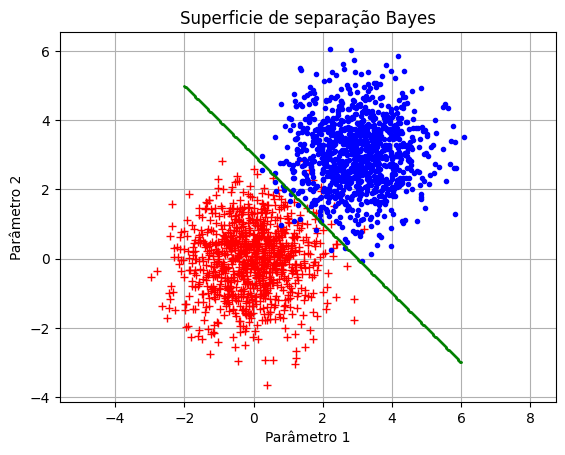

h(mu1) = -3.0
h(mu2) = 3.0
h(ponto médio) = 0.0


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# --- Parâmetros do enunciado (Questão 1) ---
mu1 = np.array([0.0, 0.0])
mu2 = np.array([3.0, 3.0])
Sigma = np.eye(2)
n_samples = 1000
rng = np.random.default_rng(42)

C1 = rng.multivariate_normal(mu1, Sigma, size=n_samples)
C2 = rng.multivariate_normal(mu2, Sigma, size=n_samples)


def h(x):
    # Função discriminante equivalente: h(x) = x1 + x2 - 3.
    x = np.atleast_2d(x)
    return x[:, 0] + x[:, 1] - 3.0


# Fronteira: x1 + x2 = 3  =>  x2 = 3 - x1
x1_line = np.linspace(-2.0, 6.0, 300)
x2_line = 3.0 - x1_line

plt.figure()
plt.plot(C1[:, 0], C1[:, 1], "r+")
plt.plot(C2[:, 0], C2[:, 1], "b.")
plt.plot(x1_line, x2_line, "g.", markersize=2)
plt.xlabel("Parâmetro 1")
plt.ylabel("Parâmetro 2")
plt.title("Superficie de separação Bayes")
plt.grid()
plt.axis("equal")
plt.show()

mid = 0.5 * (mu1 + mu2)
print("h(mu1) =", float(np.squeeze(h(mu1.reshape(1, -1)))))
print("h(mu2) =", float(np.squeeze(h(mu2.reshape(1, -1)))))
print("h(ponto médio) =", float(np.squeeze(h(mid.reshape(1, -1)))))


### Verificação com classificador explícito

Comparamos a regra $h(\mathbf{x})$ com a decisão ótima de Bayes usando densidades Gaussianas (mesmo modelo do enunciado).

In [2]:
from scipy.stats import multivariate_normal

pdf1 = multivariate_normal(mean=mu1, cov=Sigma)
pdf2 = multivariate_normal(mean=mu2, cov=Sigma)
prior = 0.5


def bayes_class(x):
    x = np.atleast_2d(x)
    log_post1 = np.log(prior) + pdf1.logpdf(x)
    log_post2 = np.log(prior) + pdf2.logpdf(x)
    return np.where(log_post1 >= log_post2, 1, 2)


def rule_h(x):
    x = np.atleast_2d(x)
    return np.where(h(x) < 0, 1, 2)


grid = rng.uniform(-1, 4, size=(50000, 2))
same = np.all(bayes_class(grid) == rule_h(grid))
print("Coincidência Bayes (log-post) vs regra h(x) em 50000 pontos aleatórios:", same)

Coincidência Bayes (log-post) vs regra h(x) em 50000 pontos aleatórios: True


---

*As questões seguintes do trabalho podem ser acrescentadas neste mesmo notebook em novas secções.*

## Questões 2 a 8 — Experimentos computacionais

A partir daqui, o notebook resolve o restante do trabalho de forma programática. A ideia é usar uma mesma função de experimento para:

- gerar os dados de treinamento da questão 2;
- calcular e estimar o erro do classificador ótimo de Bayes da questão 3;
- gerar o conjunto de teste da questão 4;
- avaliar os classificadores Euclidiano, Bayes ingênuo não paramétrico e k-NN das questões 5, 6 e 7;
- repetir todo o processo para a nova configuração da questão 8.

Para manter os resultados reproduzíveis no Colab, as sementes são sorteadas uma vez a partir de uma semente-mestre fixa.

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from scipy.stats import multivariate_normal, norm, gaussian_kde
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

try:
    import pandas as pd
except ImportError:
    pd = None

try:
    from IPython.display import display as ipython_display
except ImportError:
    ipython_display = None


# Sorteio reproduzível das sementes exigidas nas questões 2 e 4.
MASTER_SEED = 2026
seed_rng = np.random.default_rng(MASTER_SEED)
SEED_Q2 = int(seed_rng.integers(0, 501))
SEED_Q4 = int(seed_rng.integers(0, 501))

print(f"Semente sorteada para a questão 2 (treinamento): {SEED_Q2}")
print(f"Semente sorteada para a questão 4 (teste): {SEED_Q4}")

FIG_DIR = Path("../documents/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)
print(f"Diretório para figuras: {FIG_DIR.resolve()}")


def generate_two_classes(mu1, mu2, sigma, seed, n=1000):
    """Gera n amostras para C1 e n amostras para C2."""
    rng = np.random.default_rng(seed)
    x1 = rng.multivariate_normal(mu1, sigma, size=n)
    x2 = rng.multivariate_normal(mu2, sigma, size=n)
    x = np.vstack([x1, x2])
    y = np.r_[np.zeros(n, dtype=int), np.ones(n, dtype=int)]  # 0=C1, 1=C2
    return x1, x2, x, y


def bayes_linear_parameters(mu1, mu2, sigma, prior1=0.5, prior2=0.5):
    """Parâmetros de h(x)=w^T x + b; decide C2 se h(x)>=0."""
    sigma_inv = np.linalg.inv(sigma)
    w = sigma_inv @ (mu2 - mu1)
    b = -0.5 * (mu2 @ sigma_inv @ mu2 - mu1 @ sigma_inv @ mu1) + np.log(prior2 / prior1)
    return w, b


def euclidean_linear_parameters(mu1_hat, mu2_hat):
    """Fronteira por menor distância Euclidiana às médias estimadas."""
    w = mu2_hat - mu1_hat
    b = -0.5 * (mu2_hat @ mu2_hat - mu1_hat @ mu1_hat)
    return w, b


def predict_linear(x, w, b):
    score = np.asarray(x) @ w + b
    return (score >= 0).astype(int)


def theoretical_error_linear(w, b, mu1, mu2, sigma1, sigma2=None, prior1=0.5, prior2=0.5):
    """Erro exato para uma regra linear quando as classes são Gaussianas."""
    if sigma2 is None:
        sigma2 = sigma1

    m1 = float(w @ mu1 + b)
    m2 = float(w @ mu2 + b)
    s1 = float(np.sqrt(w @ sigma1 @ w))
    s2 = float(np.sqrt(w @ sigma2 @ w))

    # C2 é escolhido se h(x)>=0.
    p_c1_to_c2 = 1.0 - norm.cdf((0.0 - m1) / s1)
    p_c2_to_c1 = norm.cdf((0.0 - m2) / s2)
    return prior1 * p_c1_to_c2 + prior2 * p_c2_to_c1


def bayes_error_closed_form(mu1, mu2, sigma):
    """Erro de Bayes para duas Gaussianas equiprováveis com mesma covariância."""
    delta2 = (mu2 - mu1) @ np.linalg.inv(sigma) @ (mu2 - mu1)
    delta = np.sqrt(delta2)
    return norm.cdf(-delta / 2.0)


def format_linear_rule(w, b, name="h"):
    return f"{name}(x) = ({w[0]:.4f}) x1 + ({w[1]:.4f}) x2 + ({b:.4f})"


def make_grid(x, margin=1.2, grid_size=180):
    x_min, y_min = x.min(axis=0) - margin
    x_max, y_max = x.max(axis=0) + margin
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, grid_size),
        np.linspace(y_min, y_max, grid_size),
    )
    grid = np.c_[xx.ravel(), yy.ravel()]
    return xx, yy, grid


def plot_data_with_linear_boundary(x1, x2, mu1, mu2, w, b, title, boundary_label=None, save_path=None):
    """Estilo semelhante ao notebook do professor: plt.plot com 'r+', 'b.', 'g.', sem legenda."""
    del mu1, mu2, boundary_label  # mantidos na assinatura por compatibilidade com chamadas existentes
    x = np.vstack([x1, x2])
    x_min, y_min = x.min(axis=0) - 1.2
    x_max, y_max = x.max(axis=0) + 1.2
    x_line = np.linspace(x_min, x_max, 500)

    plt.figure()
    plt.plot(x1[:, 0], x1[:, 1], "r+")
    plt.plot(x2[:, 0], x2[:, 1], "b.")
    if abs(w[1]) > 1e-12:
        y_line = -(w[0] * x_line + b) / w[1]
        plt.plot(x_line, y_line, "g.", markersize=2)
    else:
        xv = np.full(300, -b / w[0])
        yv = np.linspace(y_min, y_max, 300)
        plt.plot(xv, yv, "g.", markersize=2)

    plt.xlabel("Parâmetro 1")
    plt.ylabel("Parâmetro 2")
    plt.title(title)
    plt.grid()
    plt.axis([x_min, x_max, y_min, y_max])
    plt.gca().set_aspect("equal", adjustable="box")
    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(save_path, dpi=180, bbox_inches="tight")
    plt.show()


class NaiveBayesKDE:
    """Bayes ingênuo com densidades marginais estimadas por KDE Gaussiano."""

    def fit(self, x, y):
        self.classes_ = np.array([0, 1])
        self.priors_ = {c: np.mean(y == c) for c in self.classes_}
        self.kdes_ = {}
        for c in self.classes_:
            xc = x[y == c]
            self.kdes_[c] = [gaussian_kde(xc[:, j]) for j in range(x.shape[1])]
        return self

    def decision_function(self, x):
        x = np.atleast_2d(x)
        log_scores = []
        for c in self.classes_:
            log_prob = np.full(x.shape[0], np.log(self.priors_[c]))
            for j, kde in enumerate(self.kdes_[c]):
                density = kde.evaluate(x[:, j])
                log_prob += np.log(np.maximum(density, 1e-300))
            log_scores.append(log_prob)
        return log_scores[1] - log_scores[0]

    def predict(self, x):
        return (self.decision_function(x) >= 0).astype(int)


def plot_classifier_boundary(clf, x1, x2, title, decision_function=None, save_path=None):
    """Fronteira aproximada por pontos verdes (amostragem), no estilo do exemplo do professor."""
    del clf
    x = np.vstack([x1, x2])
    x_min, y_min = x.min(axis=0) - 1.2
    x_max, y_max = x.max(axis=0) + 1.2
    rng = np.random.default_rng(3)
    pts = rng.uniform(low=[x_min, y_min], high=[x_max, y_max], size=(35000, 2))
    if decision_function is None:
        raise ValueError("decision_function é necessário para este gráfico.")
    aux = decision_function(pts).ravel()
    thr = max(float(np.quantile(np.abs(aux), 0.02)), 5e-4)
    superf = pts[np.abs(aux) < thr]

    plt.figure()
    plt.plot(x1[:, 0], x1[:, 1], "r+")
    plt.plot(x2[:, 0], x2[:, 1], "b.")
    plt.plot(superf[:, 0], superf[:, 1], "g.", markersize=2)
    plt.xlabel("Parâmetro 1")
    plt.ylabel("Parâmetro 2")
    plt.title(title)
    plt.grid()
    plt.axis([x_min, x_max, y_min, y_max])
    plt.gca().set_aspect("equal", adjustable="box")
    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(save_path, dpi=180, bbox_inches="tight")
    plt.show()


def plot_knn_boundaries(x_train, y_train, x1, x2, k_values, title_prefix=None, save_k=None, save_dir=None, save_prefix="knn"):
    del title_prefix
    x = np.vstack([x1, x2])
    xx, yy, grid = make_grid(x, grid_size=160)
    x_min, y_min = float(xx.min()), float(yy.min())
    x_max, y_max = float(xx.max()), float(yy.max())

    save_k = set(save_k or [])
    save_dir = Path(save_dir) if save_dir is not None else None

    classifiers = {}
    for k in k_values:
        clf = KNeighborsClassifier(n_neighbors=k)
        clf.fit(x_train, y_train)
        classifiers[k] = clf
        pred = clf.predict(grid).reshape(xx.shape)

        fig_tmp, ax_tmp = plt.subplots(figsize=(1, 1))
        cs = ax_tmp.contour(xx, yy, pred, levels=[0.5])
        segs = cs.allsegs[0] if hasattr(cs, "allsegs") and len(cs.allsegs) > 0 else []
        plt.close(fig_tmp)

        plt.figure()
        plt.plot(x1[:, 0], x1[:, 1], "r+")
        plt.plot(x2[:, 0], x2[:, 1], "b.")
        for seg in segs:
            plt.plot(seg[:, 0], seg[:, 1], "g.", markersize=2)
        plt.xlabel("Parâmetro 1")
        plt.ylabel("Parâmetro 2")
        plt.title(f"Superfície de separação k-NN (k={k})")
        plt.grid()
        plt.axis([x_min, x_max, y_min, y_max])
        plt.gca().set_aspect("equal", adjustable="box")
        if save_dir is not None and k in save_k:
            save_dir.mkdir(parents=True, exist_ok=True)
            plt.savefig(save_dir / f"{save_prefix}_k{k}.png", dpi=180, bbox_inches="tight")
        plt.show()

    return classifiers


def display_results(rows):
    if pd is not None:
        df = pd.DataFrame(rows)
        if ipython_display is not None:
            ipython_display(df)
        else:
            print(df.to_string())
        return df

    for row in rows:
        print(row)
    return rows


def run_full_experiment(name, mu1, mu2, sigma, seed_train, seed_test, n=1000, save_main_figures=True):
    mu1 = np.asarray(mu1, dtype=float)
    mu2 = np.asarray(mu2, dtype=float)
    sigma = np.asarray(sigma, dtype=float)

    slug = (
        name.lower()
        .replace("ã", "a")
        .replace("ç", "c")
        .replace("ô", "o")
        .replace("õ", "o")
        .replace("á", "a")
        .replace("é", "e")
        .replace("í", "i")
        .replace("ó", "o")
        .replace("ú", "u")
        .replace(" ", "_")
        .replace("-", "_")
    )
    slug = "".join(ch for ch in slug if ch.isalnum() or ch == "_")
    fig_dir_cfg = FIG_DIR / slug

    print("\n" + "=" * 90)
    print(name)
    print("=" * 90)
    print(f"mu1 = {mu1}")
    print(f"mu2 = {mu2}")
    print(f"Sigma =\n{sigma}")

    # Questão 2: dados de treinamento e superfície de Bayes.
    x1_train, x2_train, x_train, y_train = generate_two_classes(mu1, mu2, sigma, seed_train, n=n)
    w_bayes, b_bayes = bayes_linear_parameters(mu1, mu2, sigma)

    print("\nQuestão 2 — dados de treinamento")
    print(f"Semente usada: {seed_train}")
    print(f"Média amostral C1: {x1_train.mean(axis=0)}")
    print(f"Média amostral C2: {x2_train.mean(axis=0)}")
    print("A superfície de separação de Bayes é linear porque as classes têm a mesma matriz de covariância.")
    print(format_linear_rule(w_bayes, b_bayes, "h_Bayes"))

    plot_data_with_linear_boundary(
        x1_train,
        x2_train,
        mu1,
        mu2,
        w_bayes,
        b_bayes,
        title="Superfície de separação Bayes",
        save_path=(fig_dir_cfg / "bayes.png") if save_main_figures else None,
    )

    # Questão 3: erro Bayes teórico e erro estimado no conjunto gerado.
    bayes_pred_train = predict_linear(x_train, w_bayes, b_bayes)
    bayes_error_train = 1.0 - accuracy_score(y_train, bayes_pred_train)
    bayes_error_theoretical = bayes_error_closed_form(mu1, mu2, sigma)
    bayes_error_theoretical_linear = theoretical_error_linear(w_bayes, b_bayes, mu1, mu2, sigma)

    # Questão 4: conjunto de teste.
    x1_test, x2_test, x_test, y_test = generate_two_classes(mu1, mu2, sigma, seed_test, n=n)
    bayes_pred_test = predict_linear(x_test, w_bayes, b_bayes)
    bayes_error_test = 1.0 - accuracy_score(y_test, bayes_pred_test)

    print("\nQuestões 3 e 4 — erro de Bayes")
    print(f"Erro teórico de Bayes (forma fechada): {bayes_error_theoretical:.4f}")
    print(f"Erro teórico de Bayes (via regra linear): {bayes_error_theoretical_linear:.4f}")
    print(f"Erro estimado nos dados da questão 2: {bayes_error_train:.4f}")
    print(f"Semente de teste da questão 4: {seed_test}")
    print(f"Erro estimado no teste: {bayes_error_test:.4f}")

    rows = [
        {
            "configuração": name,
            "classificador": "Bayes ótimo",
            "erro_teórico": bayes_error_theoretical,
            "erro_treinamento": bayes_error_train,
            "erro_teste": bayes_error_test,
        }
    ]

    # Questão 5: classificador Euclidiano.
    # Há dois objetos pedidos pelo enunciado:
    #  (a) função discriminante TEÓRICA do Euclidiano — usa as médias verdadeiras
    #      (μ_1, μ_2) e ignora a estrutura de Σ. Sua probabilidade de erro também
    #      é teórica, calculada contra as Gaussianas verdadeiras.
    #  (b) função discriminante EMPÍRICA — usa as médias amostrais do treino.
    #      Avaliamos seu desempenho no conjunto de teste.
    w_euc_th, b_euc_th = euclidean_linear_parameters(mu1, mu2)
    euc_th_error_theoretical = theoretical_error_linear(w_euc_th, b_euc_th, mu1, mu2, sigma)

    mu1_hat = x1_train.mean(axis=0)
    mu2_hat = x2_train.mean(axis=0)
    w_euc, b_euc = euclidean_linear_parameters(mu1_hat, mu2_hat)
    euc_pred_test = predict_linear(x_test, w_euc, b_euc)
    euc_error_test = 1.0 - accuracy_score(y_test, euc_pred_test)
    euc_error_theoretical = theoretical_error_linear(w_euc, b_euc, mu1, mu2, sigma)

    print("\nQuestão 5 — classificador Euclidiano")
    print("Regra teórica (médias verdadeiras):")
    print("  " + format_linear_rule(w_euc_th, b_euc_th, "h_Euc_teorico"))
    print(f"  Erro teórico (regra teórica): {euc_th_error_theoretical:.4f}")
    print("Regra empírica (médias amostrais):")
    print(f"  Média estimada C1: {mu1_hat}")
    print(f"  Média estimada C2: {mu2_hat}")
    print("  " + format_linear_rule(w_euc, b_euc, "h_Euc_empirico"))
    print(f"  Erro teórico (regra empírica avaliada nas Gaussianas verdadeiras): {euc_error_theoretical:.4f}")
    print(f"  Erro no conjunto de teste: {euc_error_test:.4f}")

    plot_data_with_linear_boundary(
        x1_train,
        x2_train,
        mu1_hat,
        mu2_hat,
        w_euc,
        b_euc,
        title="Superfície de separação Euclidiana",
        save_path=(fig_dir_cfg / "euclidiano.png") if save_main_figures else None,
    )

    rows.append(
        {
            "configuração": name,
            "classificador": "Euclidiano teórico (μ verdadeiros)",
            "erro_teórico": euc_th_error_theoretical,
            "erro_treinamento": np.nan,
            "erro_teste": np.nan,
        }
    )
    rows.append(
        {
            "configuração": name,
            "classificador": "Euclidiano empírico (médias estimadas)",
            "erro_teórico": euc_error_theoretical,
            "erro_treinamento": np.nan,
            "erro_teste": euc_error_test,
        }
    )

    # Questão 6: Bayes ingênuo não paramétrico por KDE marginal.
    nb_kde = NaiveBayesKDE().fit(x_train, y_train)
    nb_pred_test = nb_kde.predict(x_test)
    nb_error_test = 1.0 - accuracy_score(y_test, nb_pred_test)

    print("\nQuestão 6 — Bayes ingênuo não paramétrico (KDE marginal)")
    print(f"Erro no conjunto de teste: {nb_error_test:.4f}")

    plot_classifier_boundary(
        nb_kde,
        x1_train,
        x2_train,
        title="Superfície de separação Bayes ingênuo",
        decision_function=nb_kde.decision_function,
        save_path=(fig_dir_cfg / "bayes_ingenuo.png") if save_main_figures else None,
    )

    rows.append(
        {
            "configuração": name,
            "classificador": "Bayes ingênuo KDE",
            "erro_teórico": np.nan,
            "erro_treinamento": np.nan,
            "erro_teste": nb_error_test,
        }
    )

    # Questão 7: k-NN com k = 1, 5, 11. Salvamos as três fronteiras
    # porque o enunciado pede a função discriminante para cada k.
    print("\nQuestão 7 — k-NN")
    knn_classifiers = plot_knn_boundaries(
        x_train,
        y_train,
        x1_train,
        x2_train,
        [1, 5, 11],
        save_k=[1, 5, 11] if save_main_figures else [],
        save_dir=fig_dir_cfg if save_main_figures else None,
        save_prefix="knn",
    )

    for k, clf in knn_classifiers.items():
        pred_test = clf.predict(x_test)
        error_test = 1.0 - accuracy_score(y_test, pred_test)
        cm = confusion_matrix(y_test, pred_test)
        print(f"k={k}: erro no teste = {error_test:.4f}; matriz de confusão = {cm.tolist()}")
        rows.append(
            {
                "configuração": name,
                "classificador": f"k-NN (k={k})",
                "erro_teórico": np.nan,
                "erro_treinamento": np.nan,
                "erro_teste": error_test,
            }
        )

    if save_main_figures:
        print(f"Figuras principais salvas em: {fig_dir_cfg.resolve()}")

    print("\nResumo de erros")
    return display_results(rows)


Semente sorteada para a questão 2 (treinamento): 426
Semente sorteada para a questão 4 (teste): 89
Diretório para figuras: C:\Users\DELL\Documents\GitHub\PatternRecognition\documents\figures


### Questões 2 a 7 — Configuração original

Configuração original usada nas questões 1 a 7:

$$
C_1 \sim \mathcal{N}\left(\begin{bmatrix}0\\0\end{bmatrix}, I\right),\qquad
C_2 \sim \mathcal{N}\left(\begin{bmatrix}3\\3\end{bmatrix}, I\right).
$$

Como as covariâncias são iguais, a superfície ótima de Bayes é uma reta. Como a covariância é identidade, a regra de Bayes coincide com a fronteira pelo ponto médio das médias.


Configuração original (Q2-Q7)
mu1 = [0. 0.]
mu2 = [3. 3.]
Sigma =
[[1. 0.]
 [0. 1.]]

Questão 2 — dados de treinamento
Semente usada: 426
Média amostral C1: [-0.00067238  0.0363345 ]
Média amostral C2: [2.97967269 3.03599474]
A superfície de separação de Bayes é linear porque as classes têm a mesma matriz de covariância.
h_Bayes(x) = (3.0000) x1 + (3.0000) x2 + (-9.0000)


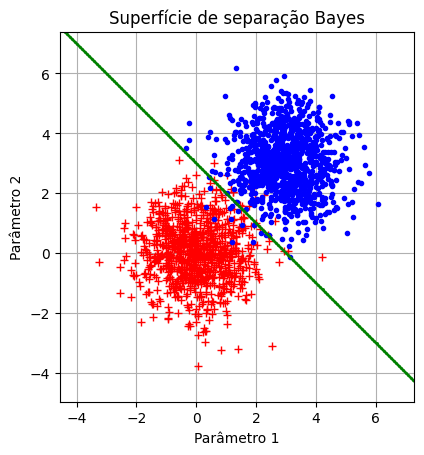


Questões 3 e 4 — erro de Bayes
Erro teórico de Bayes (forma fechada): 0.0169
Erro teórico de Bayes (via regra linear): 0.0169
Erro estimado nos dados da questão 2: 0.0155
Semente de teste da questão 4: 89
Erro estimado no teste: 0.0120

Questão 5 — classificador Euclidiano
Regra teórica (médias verdadeiras):
  h_Euc_teorico(x) = (3.0000) x1 + (3.0000) x2 + (-9.0000)
  Erro teórico (regra teórica): 0.0169
Regra empírica (médias amostrais):
  Média estimada C1: [-0.00067238  0.0363345 ]
  Média estimada C2: [2.97967269 3.03599474]
  h_Euc_empirico(x) = (2.9803) x1 + (2.9997) x2 + (-9.0472)
  Erro teórico (regra empírica avaliada nas Gaussianas verdadeiras): 0.0170
  Erro no conjunto de teste: 0.0125


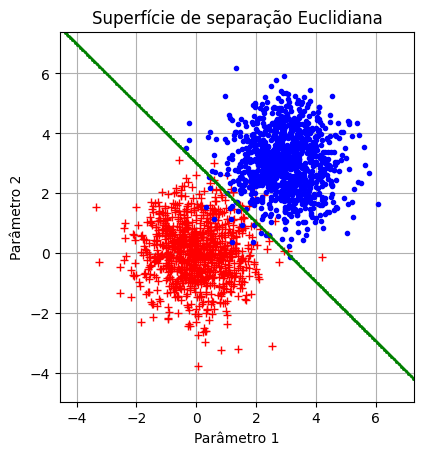


Questão 6 — Bayes ingênuo não paramétrico (KDE marginal)
Erro no conjunto de teste: 0.0155


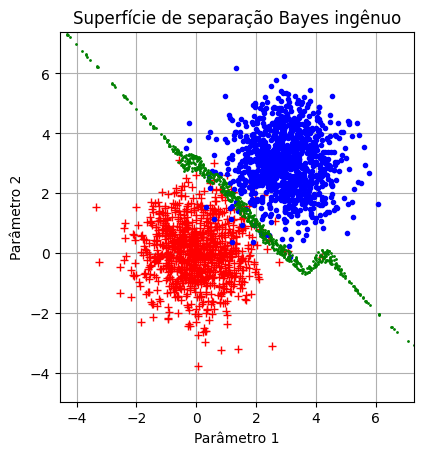


Questão 7 — k-NN


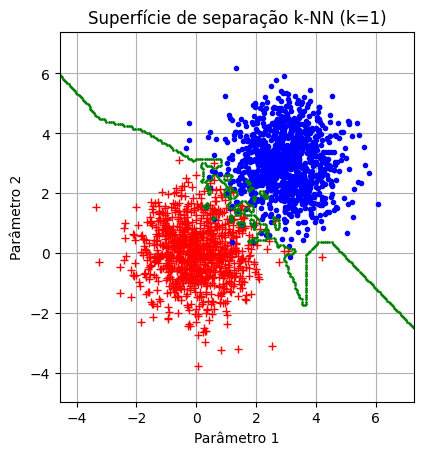

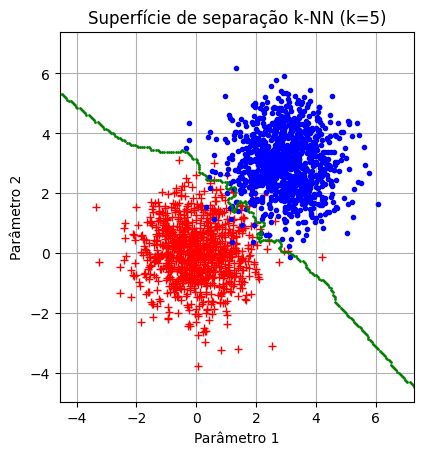

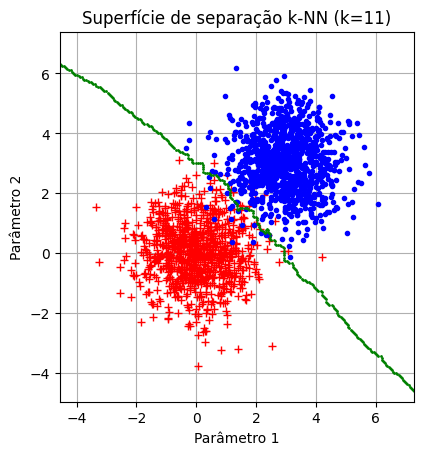

k=1: erro no teste = 0.0245; matriz de confusão = [[980, 20], [29, 971]]
k=5: erro no teste = 0.0170; matriz de confusão = [[985, 15], [19, 981]]
k=11: erro no teste = 0.0145; matriz de confusão = [[987, 13], [16, 984]]
Figuras principais salvas em: C:\Users\DELL\Documents\GitHub\PatternRecognition\documents\figures\configuracao_original_q2_q7

Resumo de erros


,configuração,classificador,erro_teórico,erro_treinamento,erro_teste
0,Configuração original (Q2-Q7),Bayes ótimo,0.016947,0.0155,0.0120
1,Configuração original (Q2-Q7),Euclidiano teórico (μ verdadeiros),0.016947,NaN,NaN
2,Configuração original (Q2-Q7),Euclidiano empírico (médias estimadas),0.016963,NaN,0.0125
3,Configuração original (Q2-Q7),Bayes ingênuo KDE,NaN,NaN,0.0155
4,Configuração original (Q2-Q7),k-NN (k=1),NaN,NaN,0.0245
5,Configuração original (Q2-Q7),k-NN (k=5),NaN,NaN,0.0170
6,Configuração original (Q2-Q7),k-NN (k=11),NaN,NaN,0.0145


In [4]:
results_original = run_full_experiment(
    name="Configuração original (Q2-Q7)",
    mu1=np.array([0.0, 0.0]),
    mu2=np.array([3.0, 3.0]),
    sigma=np.eye(2),
    seed_train=SEED_Q2,
    seed_test=SEED_Q4,
    n=1000,
)

### Questão 8 — Nova configuração das classes

Agora repetimos todos os casos anteriores para:

$$
C_1 \sim \mathcal{N}\left(\begin{bmatrix}0\\0\end{bmatrix},
\begin{bmatrix}1 & 0.6\\0.6 & 1\end{bmatrix}\right),\qquad
C_2 \sim \mathcal{N}\left(\begin{bmatrix}2\\0\end{bmatrix},
\begin{bmatrix}1 & 0.6\\0.6 & 1\end{bmatrix}\right).
$$

A superfície ótima continua sendo linear, pois a matriz de covariância é a mesma nas duas classes. Entretanto, como a covariância não é identidade, a direção da fronteira de Bayes é definida pela distância de Mahalanobis, não apenas pela distância Euclidiana.


Questão 8 — nova configuração
mu1 = [0. 0.]
mu2 = [2. 0.]
Sigma =
[[1.  0.6]
 [0.6 1. ]]

Questão 2 — dados de treinamento
Semente usada: 426
Média amostral C1: [-0.01564789  0.01685068]
Média amostral C2: [2.00208397 0.03427864]
A superfície de separação de Bayes é linear porque as classes têm a mesma matriz de covariância.
h_Bayes(x) = (3.1250) x1 + (-1.8750) x2 + (-3.1250)


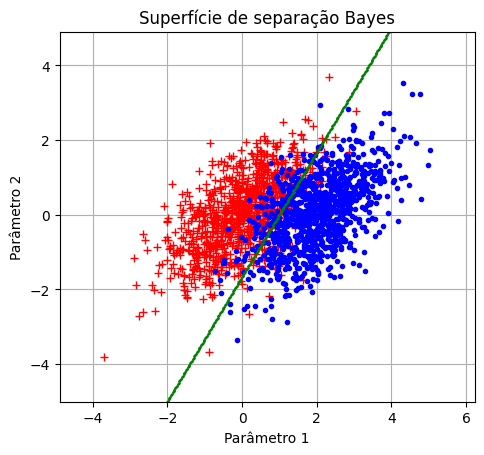


Questões 3 e 4 — erro de Bayes
Erro teórico de Bayes (forma fechada): 0.1056
Erro teórico de Bayes (via regra linear): 0.1056
Erro estimado nos dados da questão 2: 0.1060
Semente de teste da questão 4: 89
Erro estimado no teste: 0.0990

Questão 5 — classificador Euclidiano
Regra teórica (médias verdadeiras):
  h_Euc_teorico(x) = (2.0000) x1 + (0.0000) x2 + (-2.0000)
  Erro teórico (regra teórica): 0.1587
Regra empírica (médias amostrais):
  Média estimada C1: [-0.01564789  0.01685068]
  Média estimada C2: [2.00208397 0.03427864]
  h_Euc_empirico(x) = (2.0177) x1 + (0.0174) x2 + (-2.0045)
  Erro teórico (regra empírica avaliada nas Gaussianas verdadeiras): 0.1599
  Erro no conjunto de teste: 0.1645


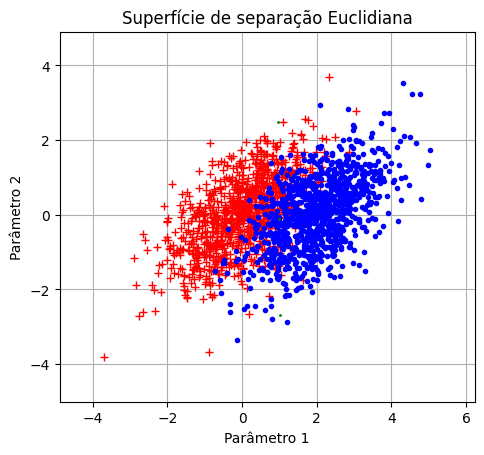


Questão 6 — Bayes ingênuo não paramétrico (KDE marginal)
Erro no conjunto de teste: 0.1620


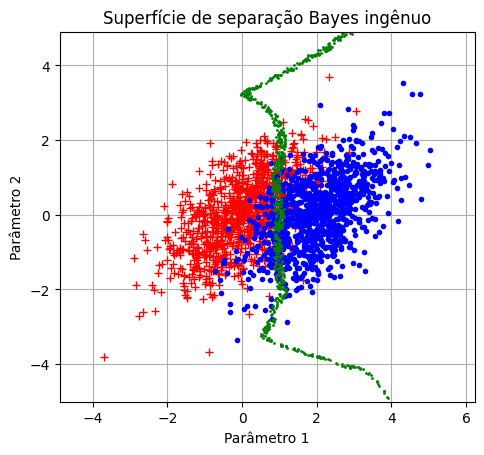


Questão 7 — k-NN


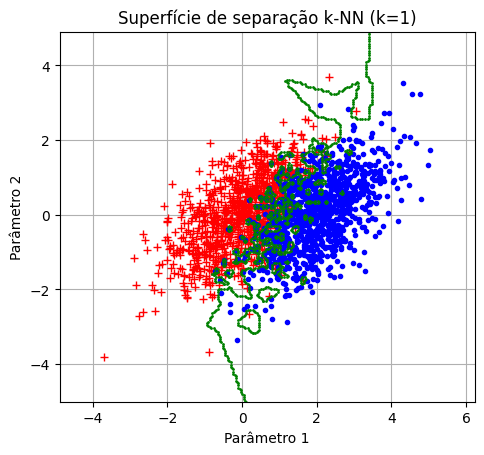

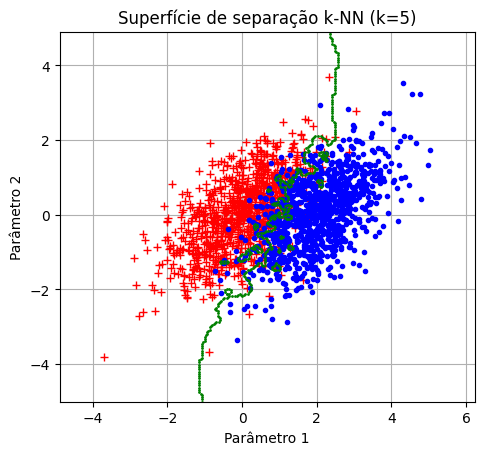

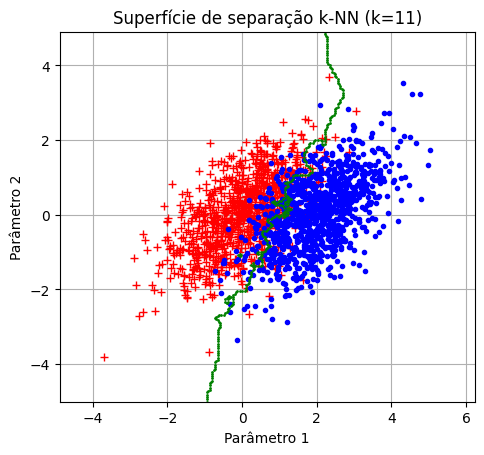

k=1: erro no teste = 0.1430; matriz de confusão = [[856, 144], [142, 858]]
k=5: erro no teste = 0.1060; matriz de confusão = [[888, 112], [100, 900]]
k=11: erro no teste = 0.0960; matriz de confusão = [[899, 101], [91, 909]]
Figuras principais salvas em: C:\Users\DELL\Documents\GitHub\PatternRecognition\documents\figures\questao_8__nova_configuracao

Resumo de erros


,configuração,classificador,erro_teórico,erro_treinamento,erro_teste
0,Questão 8 — nova configuração,Bayes ótimo,0.105650,0.106,0.0990
1,Questão 8 — nova configuração,Euclidiano teórico (μ verdadeiros),0.158655,NaN,NaN
2,Questão 8 — nova configuração,Euclidiano empírico (médias estimadas),0.159917,NaN,0.1645
3,Questão 8 — nova configuração,Bayes ingênuo KDE,NaN,NaN,0.1620
4,Questão 8 — nova configuração,k-NN (k=1),NaN,NaN,0.1430
5,Questão 8 — nova configuração,k-NN (k=5),NaN,NaN,0.1060
6,Questão 8 — nova configuração,k-NN (k=11),NaN,NaN,0.0960


In [5]:
results_q8 = run_full_experiment(
    name="Questão 8 — nova configuração",
    mu1=np.array([0.0, 0.0]),
    mu2=np.array([2.0, 0.0]),
    sigma=np.array([[1.0, 0.6], [0.6, 1.0]]),
    seed_train=SEED_Q2,
    seed_test=SEED_Q4,
    n=1000,
)

### Comentário geral dos resultados esperados

Na configuração original, as classes estão bem separadas em relação à variância unitária, portanto o erro teórico de Bayes deve ser pequeno. O classificador Euclidiano tende a se aproximar muito do Bayes ótimo porque, nesse caso, $\Sigma=I$.

Na questão 8, as classes ficam mais próximas e apresentam correlação positiva entre os parâmetros. Por isso, espera-se aumento da probabilidade de erro. A fronteira de Bayes ainda é uma reta, mas passa a considerar a geometria induzida por $\Sigma^{-1}$; assim, ela pode diferir da fronteira Euclidiana construída somente com as médias.

Para o k-NN, $k=1$ tende a produzir fronteiras mais irregulares e maior sensibilidade ao ruído. Valores maiores, como $k=5$ e $k=11$, suavizam a fronteira, podendo melhorar a generalização quando há sobreposição moderada entre as classes.